In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from scipy import stats

In [6]:
df = pd.read_csv('~/Downloads/FakeNewsNet.csv')

In [7]:
df

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1
...,...,...,...,...,...
23191,Pippa Middleton wedding: In case you missed it...,https://www.express.co.uk/news/royal/807049/pi...,www.express.co.uk,52,1
23192,Zayn Malik & Gigi Hadid’s Shocking Split: Why ...,hollywoodlife.com/2018/03/13/zayn-malik-gigi-h...,hollywoodlife.com,7,0
23193,Jessica Chastain Recalls the Moment Her Mother...,http://www.justjared.com/2018/01/17/jessica-ch...,www.justjared.com,26,1
23194,"Tristan Thompson Feels ""Dumped"" After Khloé Ka...",www.intouchweekly.com/posts/tristan-thompson-f...,www.intouchweekly.com,24,0


In [8]:
#вычислим количественные переменные для колонки tweet_num
col = 'tweet_num'
mean_val = df[col].mean()
median_val = df[col].median()
min_val = df[col].min()
max_val = df[col].max()
std_val = df[col].std()
var_val = df[col].var()
CV_val = (std_val / mean_val) * 100 if mean_val != 0 else np.nan
col = 'tweet_num'
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1 #межквартильный размах
skew = df[col].skew() #ассиметрия
kurt = df[col].kurtosis() #эксцесс 
p95 = df[col].quantile(0.95)
p99 = df[col].quantile(0.99)
sparsity = (df[col] == 0).mean() # Разреженность (доля нулевых значений)

print(f"СТАТИСТИКИ ДЛЯ ПРИЗНАКА '{col}'")
print(f"Среднее (mean):           {mean_val:.4f}")
print(f"Медиана (median):         {median_val:.4f}")
print(f"Минимум (min):            {min_val}")
print(f"Максимум (max):           {max_val}")
print(f"Станд. отклонение (std):  {std_val:.4f}")
print(f"Дисперсия (var):          {var_val:.4f}")
print(f"Коэффициент вариации:     {CV_val:.2f}%")
print(f"Q1 (25%):                 {q1:.4f}")
print(f"Q3 (75%):                 {q3:.4f}")
print(f"IQR:                      {iqr:.4f}")
print(f"Асимметрия:               {skew:.4f}")
print(f"Эксцесс:                  {kurt:.4f}")
print(f"95-й процентиль:          {p95:.4f}")
print(f"99-й процентиль:          {p99:.4f}")
print(f"Разреженность (доля 0):   {sparsity:.4%}")
print('ИНФОРМАЦИЯ О ДАННЫХ')
df.info()

print('\nПРОВЕРКА ПРОПУСКОВ')
print(df.isnull().sum())

print('\nУНИКАЛЬНЫЕ ЗНАЧЕНИЯ В КАТЕГОРИАЛЬНЫХ ПРИЗНАКАХ')
print('source_domain уникальных значений:', df['source_domain'].nunique())
print('real уникальных значений:', df['real'].nunique())

СТАТИСТИКИ ДЛЯ ПРИЗНАКА 'tweet_num'
Среднее (mean):           88.9568
Медиана (median):         37.0000
Минимум (min):            0
Максимум (max):           29060
Станд. отклонение (std):  488.6946
Дисперсия (var):          238822.4041
Коэффициент вариации:     549.36%
Q1 (25%):                 11.0000
Q3 (75%):                 65.0000
IQR:                      54.0000
Асимметрия:               33.3967
Эксцесс:                  1502.4831
95-й процентиль:          218.0000
99-й процентиль:          1020.0000
Разреженность (доля 0):   6.4709%
ИНФОРМАЦИЯ О ДАННЫХ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          23196 non-null  object
 1   news_url       22866 non-null  object
 2   source_domain  22866 non-null  object
 3   tweet_num      23196 non-null  int64 
 4   real           23196 non-null  int64 
dtypes: int64(2), objec

In [48]:
print("АНАЛИЗ КАТЕГОРИАЛЬНОГО ПРИЗНАКА 'source_domain'")
domain_counts = df['source_domain'].value_counts() #сколько раз встречается каждый элемент
domain_freq = df['source_domain'].value_counts(normalize=True) * 100 #То же самое в процентах

print(f"Уникальных доменов: {df['source_domain'].nunique()}")
print(f"Пропусков: {df['source_domain'].isnull().sum()}")
print("Топ-10 доменов по частоте:")
print(pd.DataFrame({'count': domain_counts.head(10), 'percent': domain_freq.head(10)})) #head - Берём первые 10 самых частых
print("\nАНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ 'real'")
real_counts = df['real'].value_counts()
real_freq = df['real'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': real_counts, 'percent': real_freq}))
print(f"Баланс классов: {real_counts[1] / real_counts[0]:.2f} (соотношение real=1(правда) к real=0(ложь))")

=== АНАЛИЗ КАТЕГОРИАЛЬНОГО ПРИЗНАКА 'source_domain' ===
Уникальных доменов: 2441
Пропусков: 330

Топ-10 доменов по частоте:
                           count   percent
source_domain                             
people.com                  1786  7.810723
www.dailymail.co.uk          964  4.215866
en.wikipedia.org             741  3.240619
www.usmagazine.com           709  3.100673
www.etonline.com             666  2.912621
www.longroom.com             549  2.400945
hollywoodlife.com            524  2.291612
www.usatoday.com             332  1.451937
www.hollywoodreporter.com    330  1.443191
variety.com                  304  1.329485

=== АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ 'real' ===
      count    percent
real                  
1     17441  75.189688
0      5755  24.810312
Баланс классов: 3.03 (соотношение real=1 к real=0)


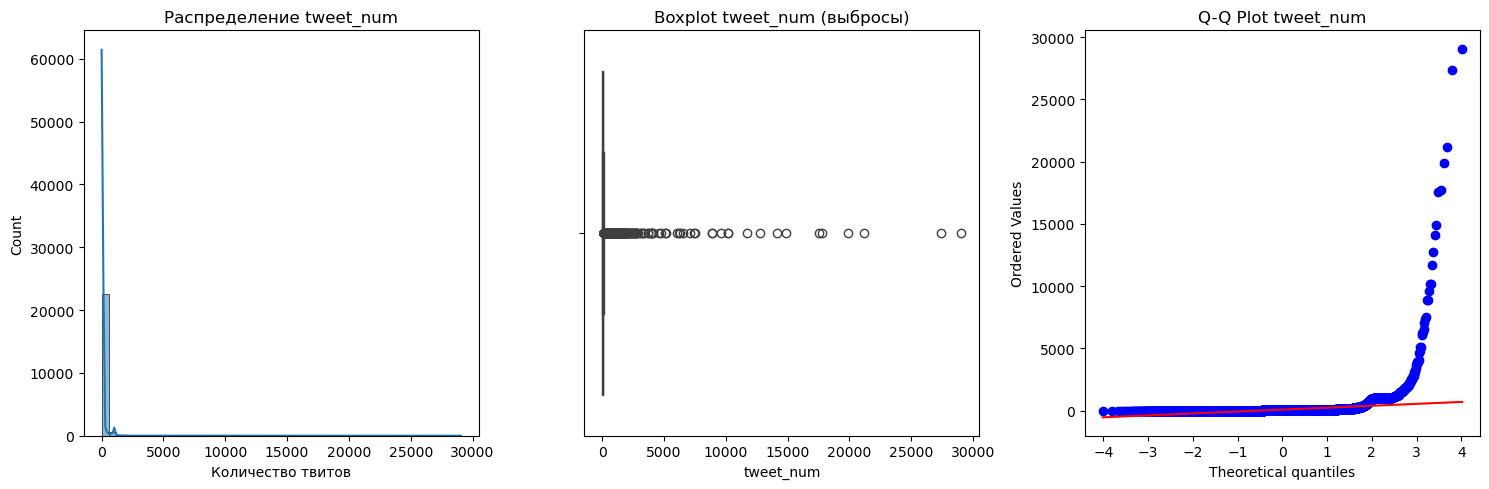

In [49]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['tweet_num'], kde=True, bins=50)
plt.title('Распределение tweet_num')
plt.xlabel('Количество твитов')
plt.subplot(1, 3, 2)
sns.boxplot(x=df['tweet_num'])
plt.title('Boxplot tweet_num (выбросы)')

# Q-Q plot для проверки нормальности
plt.subplot(1, 3, 3)
stats.probplot(df['tweet_num'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot tweet_num')
plt.tight_layout()
plt.show()

In [50]:
# Метод IQR
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"Выбросов по IQR: {len(outliers_iqr)} ({len(outliers_iqr)/len(df):.2%})")

# Метод Z-score (|z| > 3)
z_scores = np.abs(stats.zscore(df[col].dropna()))
outliers_z = df[(z_scores > 3)]
print(f"Выбросов по Z-score (>3σ): {len(outliers_z)} ({len(outliers_z)/len(df):.2%})")

# Для лабораторной работы можно создать копию датафрейма и выполнить очистку
df_clean = df.copy()

# Пример: замена выбросов на медиану (можно также удалить строки)
# Здесь закомментировано, но можно раскомментировать при необходимости
# df_clean.loc[df_clean[col] > upper_bound, col] = median_val
# df_clean.loc[df_clean[col] < lower_bound, col] = median_val

Выбросов по IQR: 1487 (6.41%)
Выбросов по Z-score (>3σ): 85 (0.37%)


In [51]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder для source_domain
le = LabelEncoder()
df_clean['domain_encoded'] = le.fit_transform(df_clean['source_domain'])
print("Пример соответствия Label Encoding:")
print(dict(zip(le.classes_[:10], le.transform(le.classes_[:10]))))
# One-Hot Encoding для топ-10 доменов, остальные в "other"
top_domains = df['source_domain'].value_counts().head(10).index
df_clean['domain_grouped'] = df_clean['source_domain'].apply(lambda x: x if x in top_domains else 'other')

# One-hot encoding
domain_dummies = pd.get_dummies(df_clean['domain_grouped'], prefix='domain', drop_first=True)
df_clean = pd.concat([df_clean, domain_dummies], axis=1)
print(f"Добавлено {domain_dummies.shape[1]} фиктивных переменных")

Пример соответствия Label Encoding:
{'1001.com.do': np.int64(0), '100percentfedup.com': np.int64(1), '101kgb.iheart.com': np.int64(2), '1029now.iheart.com': np.int64(3), '1037theq.iheart.com': np.int64(4), '1043myfm.iheart.com': np.int64(5), '1061kissfm.iheart.com': np.int64(6), '1iota.com': np.int64(7), '234today.com': np.int64(8), '24trueinfoamerica.com': np.int64(9)}
Добавлено 10 фиктивных переменных


In [52]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_clean['tweet_num_scaled'] = scaler.fit_transform(df_clean[['tweet_num']])

# Проверка статистик после масштабирования
print("После RobustScaler:")
print(f"Медиана = {df_clean['tweet_num_scaled'].median():.4f}")
print(f"IQR = {df_clean['tweet_num_scaled'].quantile(0.75) - df_clean['tweet_num_scaled'].quantile(0.25):.4f}")

После RobustScaler:
Медиана = 0.0000
IQR = 1.0000


In [53]:
scaled_skew = df_clean['tweet_num_scaled'].skew()
scaled_kurt = df_clean['tweet_num_scaled'].kurtosis()
print(f"Скос после масштабирования: {scaled_skew:.4f}")
print(f"Эксцесс после масштабирования: {scaled_kurt:.4f}")

Скос после масштабирования: 33.3967
Эксцесс после масштабирования: 1502.4831


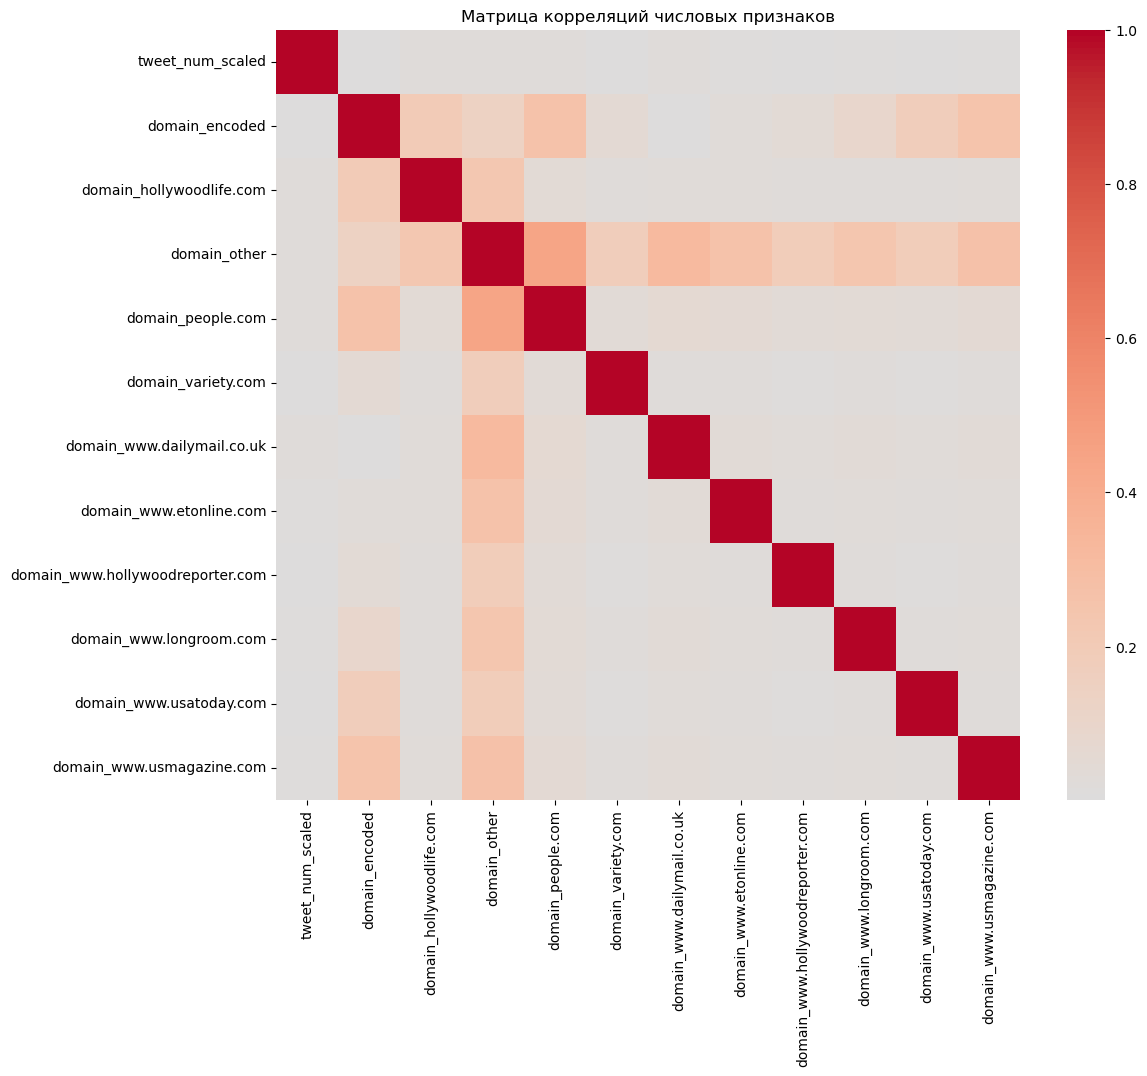

Признаки с высокой корреляцией для удаления: []
Размерность до снижения: 18 признаков
Размерность после снижения: 18 признаков
Снижение числа признаков: 0.00%


In [54]:
# Выберем все числовые признаки (включая one-hot фичи и tweet_num_scaled)
numeric_cols = ['tweet_num_scaled'] + [
    col for col in df_clean.columns 
    if col.startswith('domain_') and pd.api.types.is_numeric_dtype(df_clean[col])
]
corr_matrix = df_clean[numeric_cols].corr().abs()

# Построим тепловую карту (может быть большой)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Матрица корреляций числовых признаков')
plt.show()

# Удаление признаков с высокой корреляцией (например, >0.9)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
print(f"Признаки с высокой корреляцией для удаления: {to_drop}")

# Удалим их из датафрейма (но оставим в отдельной версии)
df_reduced = df_clean.drop(columns=to_drop)
print(f"Размерность до снижения: {df_clean.shape[1]} признаков")
print(f"Размерность после снижения: {df_reduced.shape[1]} признаков")
reduction_percent = (1 - df_reduced.shape[1] / df_clean.shape[1]) * 100
print(f"Снижение числа признаков: {reduction_percent:.2f}%")

In [55]:
# Бинирование tweet_num на 5 интервалов
bins = [0, 20, 40, 60, 80, np.inf]
labels = ['very_low', 'low', 'medium', 'high', 'very_high']
df_clean['tweet_num_binned'] = pd.cut(df_clean['tweet_num'], bins=bins, labels=labels, right=False)

# Кодируем бины обратно в числовые метки (для сравнения)
bin_mapping = {label: i for i, label in enumerate(labels)}
df_clean['tweet_num_bin_code'] = df_clean['tweet_num_binned'].map(bin_mapping)
def bin_center(bin_label):
    if bin_label == 'very_low': return 10
    elif bin_label == 'low': return 30
    elif bin_label == 'medium': return 50
    elif bin_label == 'high': return 70
    else: return 90


df_clean['bin_center'] = df_clean['tweet_num_binned'].apply(bin_center).astype(float)

mse_binning = np.mean((df_clean['tweet_num'] - df_clean['bin_center']) ** 2)
print(f"Среднеквадратичная ошибка бинирования: {mse_binning:.2f}")

Среднеквадратичная ошибка бинирования: 235369.82


In [56]:
end_time = time.time()
metrics = {
    "Процент очищенных данных": "100% (нет пропусков)",
    "Доля восстанавливаемых данных": "0% (не было пропусков)",
    "Скос нормализованного признака": scaled_skew,
    "Эксцесс нормализованного признака": scaled_kurt,
    "Качество бинирования (MSE)": mse_binning,
    "Снижение размерности": f"{reduction_percent:.2f}%"
}
metrics_df = pd.DataFrame(metrics.items(), columns=["Метрика", "Значение"])
print(metrics_df)

                             Метрика                Значение
0           Процент очищенных данных    100% (нет пропусков)
1                    Время обработки               27.30 сек
2      Доля восстанавливаемых данных  0% (не было пропусков)
3     Скос нормализованного признака               33.396672
4  Эксцесс нормализованного признака             1502.483062
5         Качество бинирования (MSE)           235369.820055
6               Снижение размерности                   0.00%
